# Parameter-recovery experiment data

Load all available FNN parameter-search JSONL results into one tidy DataFrame. Each row is one training epoch; `parameter_trace` contains the learned-versus-true physical parameters recorded at that epoch. This notebook intentionally starts with loading and completeness checks only.

In [11]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / 'derived').is_dir() else Path.cwd().parent
RESULTS_DIRS = [
    REPO_ROOT / 'derived' / 'results' / 'parameter_recovery',
    REPO_ROOT / 'derived' / 'results' / 'parameter_recovery_controlled',
    REPO_ROOT / 'derived' / 'results' / 'parameter_recovery_controlled_nodecay',
]

FILENAME_PATTERN = re.compile(
    r'^paramrecovery_(?:(?P<stage>gamma|omega|force_scale|topology|joint)_)?(?P<dynamic>diffusion|wave|coupled_oscillator)_'
    r'(?P<topology>[^_]+)_'
    r'(?P<parameter>gamma|omega|force_scale|topology)init(?P<initial_value>[^_]+)_'
    r'models(?P<models>\d+)_epochs(?P<epochs>\d+)_nodes(?P<num_nodes>\d+)_'
    r'episodes(?P<num_episodes>\d+)_bins(?P<num_bins>\d+)_events(?P<events_per_bin>\d+)_'
    r'dropint(?P<raindrop_interval>\d+)_tau(?P<event_threshold>[^_]+)_'
    r'trainroll(?P<rollout_train_steps>\d+)_rollhorizon(?P<rollout_horizon>\d+)_seed(?P<seed>\d+)\.jsonl$'
)


In [12]:
def decode_numeric_tag(value: str) -> float:
    return float(value.replace('p', '.').replace('m', '-'))


def load_parameter_results(results_dirs: list[Path]) -> pd.DataFrame:
    paths = sorted(path for results_dir in results_dirs if results_dir.exists()
                   for path in results_dir.glob('paramrecovery_*.jsonl'))
    if not paths:
        raise FileNotFoundError(f'No parameter-recovery JSONLs found in {results_dirs}')

    records: list[dict] = []
    for path in paths:
        match = FILENAME_PATTERN.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Unexpected parameter-recovery filename: {path.name}')

        file_meta = match.groupdict()
        file_meta['stage'] = file_meta['stage'] or 'joint_uncontrolled'
        for key in ('models', 'epochs', 'num_nodes', 'num_episodes', 'num_bins',
                    'events_per_bin', 'raindrop_interval', 'rollout_train_steps',
                    'rollout_horizon', 'seed'):
            file_meta[key] = int(file_meta[key])
        file_meta['initial_value'] = decode_numeric_tag(file_meta['initial_value'])
        file_meta['event_threshold'] = decode_numeric_tag(file_meta['event_threshold'])
        file_meta['source_file'] = path.name

        for line_number, line in enumerate(path.read_text().splitlines(), start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f'Invalid JSON in {path}:{line_number}') from exc
            record.update(file_meta)
            records.append(record)

    return pd.json_normalize(records, sep='.')


parameter_df = load_parameter_results(RESULTS_DIRS)
parameter_df.head()


,run,seed,epoch,stage,dynamic,topology,parameter,initial_value,models,epochs,...,test.learned_omega,test.true_omega,test.omega_abs_error,recovery.learned_omega,recovery.true_omega,recovery.omega_abs_error,model_cfg.fnn_learn_gamma,model_cfg.fnn_learn_omega,model_cfg.fnn_learn_force_scale,model_cfg.fnn_oracle_topology
0,fnn,0,1,joint_uncontrolled,diffusion,ring,force_scale,0.2,1,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fnn,0,2,joint_uncontrolled,diffusion,ring,force_scale,0.2,1,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fnn,0,3,joint_uncontrolled,diffusion,ring,force_scale,0.2,1,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fnn,0,4,joint_uncontrolled,diffusion,ring,force_scale,0.2,1,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fnn,0,5,joint_uncontrolled,diffusion,ring,force_scale,0.2,1,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Availability and run completeness. A run has its final evaluation row once epoch == epochs.
print('Rows:', len(parameter_df))
print('Columns:', len(parameter_df.columns))

run_status = (
    parameter_df.groupby(['dynamic', 'topology', 'parameter', 'initial_value', 'seed', 'source_file'], observed=True)
    .agg(last_epoch=('epoch', 'max'), planned_epochs=('epochs', 'first'), rows=('epoch', 'size'))
    .reset_index()
)
run_status['complete'] = run_status['last_epoch'].eq(run_status['planned_epochs'])
display(run_status.sort_values(['dynamic', 'parameter', 'initial_value', 'seed']))

trace_columns = [column for column in parameter_df.columns if column.startswith('parameter_trace.')]
print('Parameter-trace columns:', trace_columns)


Rows: 8494
Columns: 10908


,dynamic,topology,parameter,initial_value,seed,source_file,last_epoch,planned_epochs,rows,complete
0,diffusion,ring,force_scale,0.2,0,paramrecovery_diffusion_ring_force_scaleinit0p...,100,100,100,True
1,diffusion,ring,force_scale,0.2,1,paramrecovery_diffusion_ring_force_scaleinit0p...,100,100,100,True
2,diffusion,ring,force_scale,0.2,2,paramrecovery_diffusion_ring_force_scaleinit0p...,100,100,100,True
3,diffusion,ring,force_scale,0.4,0,paramrecovery_diffusion_ring_force_scaleinit0p...,100,100,100,True
4,diffusion,ring,force_scale,0.4,1,paramrecovery_diffusion_ring_force_scaleinit0p...,100,100,100,True
...,...,...,...,...,...,...,...,...,...,...
81,wave,ring,topology,-2.0,1,paramrecovery_wave_ring_topologyinit-2_models1...,100,100,100,True
82,wave,ring,topology,0.0,0,paramrecovery_wave_ring_topologyinit0_models1_...,100,100,100,True
83,wave,ring,topology,0.0,1,paramrecovery_wave_ring_topologyinit0_models1_...,100,100,100,True
84,wave,ring,topology,2.0,0,paramrecovery_wave_ring_topologyinit2_models1_...,100,100,100,True


Parameter-trace columns: ['parameter_trace.topology_auc', 'parameter_trace.topology_f1', 'parameter_trace.learned_gamma', 'parameter_trace.true_gamma', 'parameter_trace.gamma_abs_error', 'parameter_trace.learned_force_scale', 'parameter_trace.true_force_scale', 'parameter_trace.force_scale_abs_error', 'parameter_trace.learned_omega', 'parameter_trace.true_omega', 'parameter_trace.omega_abs_error']


In [14]:
PARAMETER_TRACE_COLS = {
    "gamma": {
        "learned": "parameter_trace.learned_gamma",
        "true": "parameter_trace.true_gamma",
        "error": "parameter_trace.gamma_abs_error",
        "label": r"$\gamma$",
    },
    "force_scale": {
        "learned": "parameter_trace.learned_force_scale",
        "true": "parameter_trace.true_force_scale",
        "error": "parameter_trace.force_scale_abs_error",
        "label": "Force scale",
    },
    "omega": {
        "learned": "parameter_trace.learned_omega",
        "true": "parameter_trace.true_omega",
        "error": "parameter_trace.omega_abs_error",
        "label": r"$\omega$",
    },
}


records = []

for parameter, cfg in PARAMETER_TRACE_COLS.items():

    sub = parameter_df[
        parameter_df["parameter"].eq(parameter)
        & parameter_df[cfg["learned"]].notna()
    ]

    for _, row in sub.iterrows():
        records.append({
            "dynamic": row["dynamic"],
            "topology": row["topology"],
            "parameter": parameter,
            "initial_value": row["initial_value"],
            "seed": row["seed"],
            "epoch": row["epoch"],
            "learned_value": row[cfg["learned"]],
            "true_value": row[cfg["true"]],
            "abs_error": row[cfg["error"]],
        })

recovery_long = (
    pd.DataFrame(records)
    .sort_values(
        ["dynamic", "parameter", "initial_value", "seed", "epoch"]
    )
    .reset_index(drop=True)
)

recovery_long

,dynamic,topology,parameter,initial_value,seed,epoch,learned_value,true_value,abs_error
0,diffusion,ring,force_scale,0.2,0,1,0.224919,0.8,0.575081
1,diffusion,ring,force_scale,0.2,0,2,0.252505,0.8,0.547495
2,diffusion,ring,force_scale,0.2,0,3,0.282915,0.8,0.517085
3,diffusion,ring,force_scale,0.2,0,4,0.315723,0.8,0.484277
4,diffusion,ring,force_scale,0.2,0,5,0.350509,0.8,0.449491
...,...,...,...,...,...,...,...,...,...
6989,wave,ring,omega,3.2,1,96,0.467153,0.8,0.332847
6990,wave,ring,omega,3.2,1,97,0.461516,0.8,0.338484
6991,wave,ring,omega,3.2,1,98,0.456619,0.8,0.343381
6992,wave,ring,omega,3.2,1,99,0.452381,0.8,0.347619


In [15]:
display(
    recovery_long
    .groupby(["dynamic", "parameter"])
    .agg(
        starts=("initial_value", lambda x: tuple(sorted(x.unique()))),
        true_values=("true_value", lambda x: tuple(sorted(x.dropna().unique()))),
        max_epoch=("epoch", "max"),
    )
    .reset_index()
)

,dynamic,parameter,starts,true_values,max_epoch
0,diffusion,force_scale,"(0.2, 0.4, 0.8, 1.6, 3.2)","(0.8,)",100
1,diffusion,gamma,"(0.045, 0.09, 0.18, 0.36, 0.72)","(0.18,)",100
2,wave,force_scale,"(0.2, 0.4, 0.8, 1.6, 3.2)","(0.8,)",100
3,wave,gamma,"(0.0375, 0.075, 0.15, 0.3, 0.6)","(0.15,)",100
4,wave,omega,"(0.2, 0.4, 0.8, 1.6, 3.2)","(0.8,)",100


In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_parameter_recovery(ax, data, *, label):

    starts = sorted(data["initial_value"].unique())
    cmap = plt.get_cmap("viridis")

    colors = {
        start: cmap(i / max(len(starts) - 1, 1))
        for i, start in enumerate(starts)
    }

    true_values = data["true_value"].dropna().unique()

    if len(true_values):
        true_value = true_values[0]

        ax.axhline(
            true_value,
            color="0.15",
            linestyle="--",
            linewidth=1.2,
            zorder=1,
        )

    for start in starts:

        g = (
            data[data["initial_value"] == start]
            .sort_values("epoch")
        )

        color = colors[start]

        ax.plot(
            g["epoch"],
            g["learned_value"],
            color=color,
            linewidth=1.3,
            alpha=0.9,
            zorder=2,
        )

        # Starting point
        ax.scatter(
            g["epoch"].iloc[0],
            g["learned_value"].iloc[0],
            s=25,
            facecolor="white",
            edgecolor=color,
            linewidth=1.2,
            zorder=4,
        )

        # Final point
        ax.scatter(
            g["epoch"].iloc[-1],
            g["learned_value"].iloc[-1],
            s=25,
            facecolor=color,
            edgecolor=color,
            linewidth=1.0,
            zorder=4,
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        color="0.9",
        linewidth=0.5,
    )

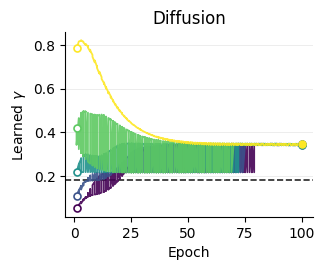

In [17]:
fig, ax = plt.subplots(figsize=(3.2, 2.4))

sub = recovery_long[
    (recovery_long["dynamic"] == "diffusion")
    & (recovery_long["parameter"] == "gamma")
]

plot_parameter_recovery(
    ax,
    sub,
    label=r"Learned $\gamma$",
)

ax.set_title("Diffusion")

plt.show()

In [18]:
recovery_long["relative_value"] = (
    recovery_long["learned_value"]
    / recovery_long["true_value"]
)


recovery_long["relative_initial"] = (
    recovery_long["initial_value"]
    / recovery_long["true_value"]
)

DYNAMIC_ORDER = [
    "diffusion",
    "wave",
]

DYNAMIC_LABELS = {
    "diffusion": "Diffusion",
    "wave": "Wave",
}

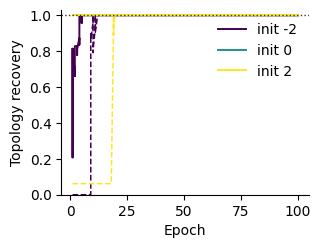

In [19]:
topology_trace = parameter_df[
    parameter_df["parameter"].eq("topology")
].copy()

fig, ax = plt.subplots(figsize=(3.2, 2.4))

starts = sorted(topology_trace["initial_value"].unique())
cmap = plt.get_cmap("viridis")

for i, start in enumerate(starts):
    g = (
        topology_trace[
            topology_trace["initial_value"].eq(start)
        ]
        .sort_values("epoch")
    )

    color = cmap(i / max(len(starts) - 1, 1))

    ax.plot(
        g["epoch"],
        g["parameter_trace.topology_auc"],
        color=color,
        linewidth=1.4,
        linestyle="-",
        label=f"init {start:g}",
    )

    ax.plot(
        g["epoch"],
        g["parameter_trace.topology_f1"],
        color=color,
        linewidth=1.1,
        linestyle="--",
    )

ax.axhline(
    1.0,
    color="0.2",
    linestyle=":",
    linewidth=1.0,
)

ax.set_ylim(0, 1.03)
ax.set_xlabel("Epoch")
ax.set_ylabel("Topology recovery")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.show()

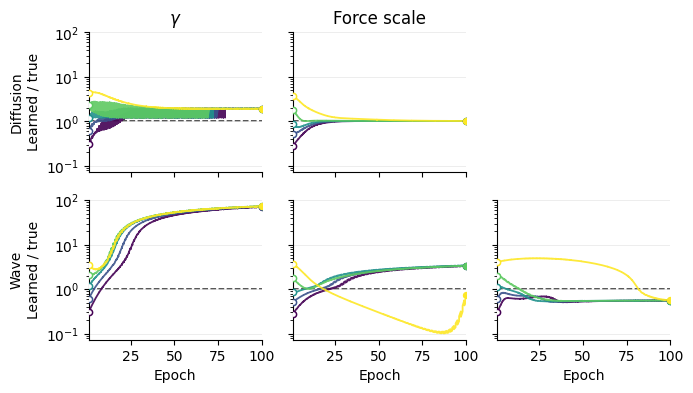

In [20]:
PARAMETER_ORDER = [
    "gamma",
    "force_scale",
    "omega",
]

PARAMETER_LABELS = {
    "gamma": r"$\gamma$",
    "force_scale": "Force scale",
    "omega": r"$\omega$",
}

DYNAMIC_ORDER = [
    "diffusion",
    "wave",
]

DYNAMIC_LABELS = {
    "diffusion": "Diffusion",
    "wave": "Wave",
}

recovery_long["relative_value"] = (
    recovery_long["learned_value"]
    / recovery_long["true_value"]
)

recovery_long["relative_initial"] = (
    recovery_long["initial_value"]
    / recovery_long["true_value"]
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(6.5, 3.8),
    sharex=True,
    sharey=True,
)

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, parameter in enumerate(PARAMETER_ORDER):

        ax = axes[row_idx, col_idx]

        data = recovery_long[
            (recovery_long["dynamic"] == dynamic)
            & (recovery_long["parameter"] == parameter)
        ]

        if data.empty:
            ax.axis("off")
            continue

        starts = sorted(data["initial_value"].unique())
        cmap = plt.get_cmap("viridis")

        colors = {
            start: cmap(i / max(len(starts) - 1, 1))
            for i, start in enumerate(starts)
        }

        # True value
        ax.axhline(
            1.0,
            color="0.15",
            linestyle="--",
            linewidth=1.1,
            zorder=1,
        )

        for start in starts:
            g = (
                data[data["initial_value"] == start]
                .sort_values("epoch")
            )

            color = colors[start]

            ax.plot(
                g["epoch"],
                g["relative_value"],
                color=color,
                linewidth=1.3,
                alpha=0.9,
                zorder=2,
            )

            # Starting point
            ax.scatter(
                g["epoch"].iloc[0],
                g["relative_value"].iloc[0],
                s=20,
                facecolor="white",
                edgecolor=color,
                linewidth=1.1,
                zorder=4,
            )

            # Final point
            ax.scatter(
                g["epoch"].iloc[-1],
                g["relative_value"].iloc[-1],
                s=20,
                facecolor=color,
                edgecolor=color,
                linewidth=0.8,
                zorder=4,
            )

        if row_idx == 0:
            ax.set_title(PARAMETER_LABELS[parameter])

        if col_idx == 0:
            ax.set_ylabel(
                f"{DYNAMIC_LABELS[dynamic]}\nLearned / true"
            )

        if row_idx == 1:
            ax.set_xlabel("Epoch")

        ax.set_yscale("log")
        ax.set_xlim(1, 100)

        ax.grid(
            axis="y",
            color="0.90",
            linewidth=0.5,
        )
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


fig.subplots_adjust(
    left=0.10,
    right=0.995,
    bottom=0.12,
    top=0.93,
    wspace=0.18,
    hspace=0.20,
)

plt.show()

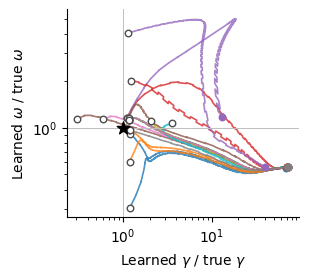

In [21]:
# Example: joint gamma–omega trajectory for wave runs
# Requires gamma and omega to be recorded in the same training runs.

wave = parameter_df[
    parameter_df["dynamic"].eq("wave")
].copy()

wave["gamma_rel"] = (
    wave["parameter_trace.learned_gamma"]
    / wave["parameter_trace.true_gamma"]
)

wave["omega_rel"] = (
    wave["parameter_trace.learned_omega"]
    / wave["parameter_trace.true_omega"]
)

fig, ax = plt.subplots(figsize=(3.0, 2.7))

for (parameter, initial_value), g in wave.groupby(
    ["parameter", "initial_value"]
):
    g = g.sort_values("epoch").dropna(
        subset=["gamma_rel", "omega_rel"]
    )

    if g.empty:
        continue

    ax.plot(
        g["gamma_rel"],
        g["omega_rel"],
        linewidth=1.2,
        alpha=0.8,
    )

    ax.scatter(
        g["gamma_rel"].iloc[0],
        g["omega_rel"].iloc[0],
        facecolor="white",
        edgecolor="0.3",
        s=22,
        zorder=3,
    )

    ax.scatter(
        g["gamma_rel"].iloc[-1],
        g["omega_rel"].iloc[-1],
        s=22,
        zorder=3,
    )

ax.scatter(
    1, 1,
    marker="*",
    s=90,
    color="black",
    zorder=5,
    label="True parameters",
)

ax.axvline(1, color="0.75", linewidth=0.7)
ax.axhline(1, color="0.75", linewidth=0.7)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Learned $\gamma$ / true $\gamma$")
ax.set_ylabel(r"Learned $\omega$ / true $\omega$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()